In [2]:
import pandas as pd
import glob
from pathlib import Path
# os.listdir('../../data/sefaz-sp/2026-03-05/')

# Funções

In [3]:
def lista_df(tipo,data='',uf='rn'):
    path_data = Path('../../data/')
    
    arquivos = path_data.rglob(f'sefaz-{uf}/**/*{tipo}*{data}*.parquet')
    arquivos = [str(a) for a in arquivos]
    arquivos.sort()
    
    print('Prossibilidades:')
    for arquivo in arquivos:
        print(arquivo)
    
    return arquivos

def apura_provas(df,uf='mt'):
    # Consolida Provas
    if uf == 'mt':
        df['p1'] = df[['por', 'rl', 'ghm', 'dt', 'efp', 'aud', 'est', 'nda', 'ing','pf',]].sum(axis=1)
        df['p2'] = df[['ti', 'lte', 'cgc', 'mf',]].sum(axis=1)
        
        df['p1_prc'] = df['p1']/(80)*100
        df['p2_prc'] = df['p2']/(80*2)*100
        df['total_prc'] = df['total']/(80+80*2)*100
        df['aprovado'] = (df['p1']>=60) & (df['p2']>=60)  & (df['total_prc']>=70) 

        df['vagas'] = df['posicao'] <= 21
        df['cr'] = df['posicao'] <= 6000
    elif uf == 'sp':
        # SP
        df['p1'] = df[['por', 'mf', 'rc', 'ing', 'agp', 'efp',]].sum(axis=1)
        df['p2'] = df[['dca', 'dt', 'lte', 'cg', 'aud',]].sum(axis=1)
        df['p3'] = df[['dta', 'lta', 'cac', 'fd',]].sum(axis=1)
        
        df['p1_prc'] = df['p1']/(100)*100
        df['p2_prc'] = df['p2']/(80)*100
        df['p3_prc'] = df['p3']/(8*20)*100
        df['total_prc'] = df['total']/(100+80*3)*100
        df['aprovado'] = (df['p1']>=50) & (df['p2']>=40) & (df['p3']>=80)  & (df['total']>=204)
        
        df['vagas'] = df['posicao'] <= 150
        df['cr'] = df['posicao'] <= 285

    return df
    

def last_df(tipo,data='',uf='rn'):
    arquivos = lista_df(tipo,data=data,uf=uf)
    arquivos.sort()
    df_nome = arquivos[-1]

    print('Carrega: {}:'.format(df_nome),end='')
    df = pd.read_parquet(df_nome)

    # Transforma valores em inteiros
    colunas_int = df.columns[2:]
    df[colunas_int] = df[colunas_int].astype(int)
    df['posicao'] = df['posicao'].str.replace('º','').str.replace('.','').astype(int)

    # Transforma Dados
    df = apura_provas(df,uf=uf)

    print(df.shape)
    print()

    return df

In [8]:
def media(df,col,posicao):
    return df[col].iloc[posicao-100:posicao].mean()

def comparacao_disciplina(df,disciplinas=[],pontos=[],pesos=None):

    if pesos is None:
        pesos = [1,]*len(disciplinas)
    
    pontuacao_total = sum([a * b for a, b in zip(pontos, pesos)])
    posicoes = [100,200,300,500]
    totais = {100:0,200:0,300:0,500:0}
    
    df_tabela = pd.DataFrame(columns=["Prova", "100°", "200°", "300°", "500°"])
    
    for n in range(0,len(disciplinas)):
        disciplina = disciplinas[n]
        pontuacao = pontos[n]
        peso = pesos[n]
        
        linha = [disciplina]
        for posicao in posicoes:
            linha.append(media(df,disciplina,posicao)/pontuacao/peso*100)
            totais[posicao] = totais[posicao] + media(df,disciplina,posicao)
    
        df_tabela.loc[df_tabela.shape[0]] = linha
    
            
    df_tabela.loc[df_tabela.shape[0]] = ['total'] + [v*100/pontuacao_total for k,v in totais.items()]
    
    return df_tabela.style.format(precision=2)

# Carrega DataFrames

In [4]:
datas = ['2026-03-05','2026-03-07',
         '2026-03-09','2026-03-10','2026-03-11','2026-03-12','2026-03-13',
         '2026-03-16']
dict_df_sp = {}
for data in datas:
    dict_df_sp[data] = last_df('pontos',data=data,uf='sp')
    
df = last_df('pontos',uf='sp')

Prossibilidades:
../../data/sefaz-sp/2026-03-05/df_pontos_2026-03-05_14-12.parquet
Carrega: ../../data/sefaz-sp/2026-03-05/df_pontos_2026-03-05_14-12.parquet:(2121, 28)

Prossibilidades:
../../data/sefaz-sp/2026-03-07/df_pontos_2026-03-07_11-05.parquet
Carrega: ../../data/sefaz-sp/2026-03-07/df_pontos_2026-03-07_11-05.parquet:(2188, 28)

Prossibilidades:
../../data/sefaz-sp/2026-03-09/df_pontos_2026-03-09_11-38.parquet
Carrega: ../../data/sefaz-sp/2026-03-09/df_pontos_2026-03-09_11-38.parquet:(2220, 28)

Prossibilidades:
../../data/sefaz-sp/2026-03-10/df_pontos_2026-03-10_13-19.parquet
Carrega: ../../data/sefaz-sp/2026-03-10/df_pontos_2026-03-10_13-19.parquet:(2237, 28)

Prossibilidades:
../../data/sefaz-sp/2026-03-11/df_pontos_2026-03-11_11-04.parquet
Carrega: ../../data/sefaz-sp/2026-03-11/df_pontos_2026-03-11_11-04.parquet:(2257, 28)

Prossibilidades:
../../data/sefaz-sp/2026-03-12/df_pontos_2026-03-12_19-21.parquet
Carrega: ../../data/sefaz-sp/2026-03-12/df_pontos_2026-03-12_19-21.

In [5]:
df_provas = df[['posicao','usuario','p1','p2','p3','total','p1_prc','p2_prc','p3_prc','total_prc']]

# Análise

In [6]:
df_provas[df_provas['usuario'] == 'cf_auditor']

,posicao,usuario,p1,p2,p3,total,p1_prc,p2_prc,p3_prc,total_prc
1079,1080,cf_auditor,48,57,108,213,48.0,71.25,67.5,62.647059


#### Análise por Colocação

In [9]:
comparacao_disciplina(df,disciplinas=['p1','p2','p3'],pontos=[100,80,80],pesos=[1,1,2])

,Prova,100°,200°,300°,500°
0,p1,75.14,70.46,67.27,63.25
1,p2,85.06,82.00,80.16,76.56
2,p3,84.94,81.29,79.51,74.85
3,total,82.09,78.27,76.06,71.84


#### Análise por P1

In [10]:
comparacao_disciplina(df,disciplinas=['por', 'mf', 'rc', 'ing', 'agp', 'efp',],pontos=[30,15,15,10,15,15])

,Prova,100°,200°,300°,500°
0,por,77.67,72.40,71.00,69.73
1,mf,70.47,65.00,59.47,54.00
2,rc,65.80,62.53,61.13,55.00
3,ing,80.50,73.80,66.70,67.60
4,agp,85.60,82.60,80.40,76.40
5,efp,70.07,65.60,61.00,51.73
6,total,75.14,70.46,67.27,63.25


#### Análise por P2

In [11]:
comparacao_disciplina(df,disciplinas=['dca', 'dt', 'lte', 'cg', 'aud',],pontos=[25,15,15,15,10])

,Prova,100°,200°,300°,500°
0,dca,78.44,75.20,71.40,68.00
1,dt,90.07,87.40,86.60,82.20
2,lte,76.87,72.73,70.20,66.47
3,cg,91.73,89.93,89.60,84.93
4,aud,96.40,92.90,93.20,92.10
5,total,85.06,82.00,80.16,76.56


#### Análise por P3

In [12]:
comparacao_disciplina(df,disciplinas=['dta', 'lta', 'cac', 'fd',],pontos=[25*2,25*2,20*2,10*2])

,Prova,100°,200°,300°,500°
0,dta,87.56,83.92,82.64,78.04
1,lta,85.48,81.76,80.56,73.56
2,cac,84.50,81.55,79.15,75.15
3,fd,77.90,73.00,69.80,69.50
4,total,84.94,81.29,79.51,74.85


# Análise Gráfica

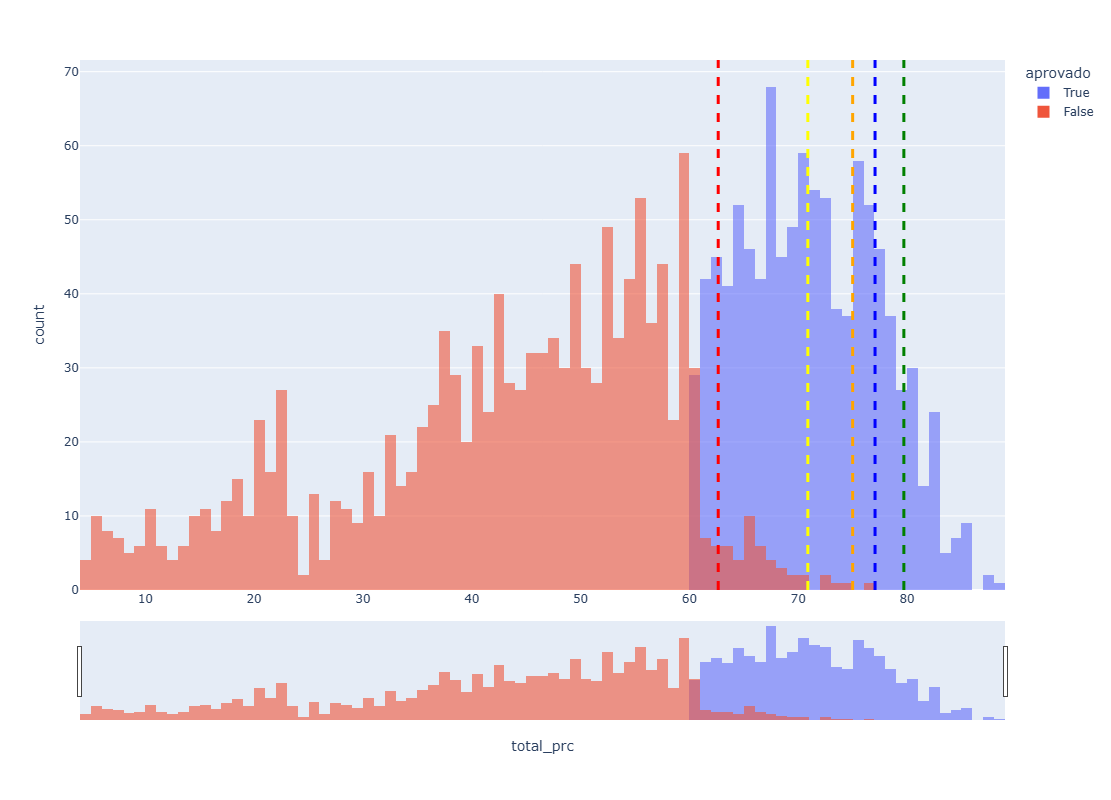

In [65]:
import plotly.express as px

df_fig = df[df['aprovado'] | True]

# df é o seu DataFrame do Pandas com os dados do ranking
# fig = px.histogram(df_fig, x="total_prc", nbins=20)

# df é o seu DataFrame do Pandas com os dados do ranking
fig = px.histogram(
    df_fig, 
    x="total_prc", 
    color="aprovado", 
    barmode='overlay',  # Este é o comando chave
    opacity=0.6,        # Opacidade para conseguir enxergar a sobreposição
    nbins=10)

# Se o total é 100 e você quer 50 bins, o size é 2
fig.update_traces(xbins=dict(
    size=1  # Força cada barra a ter largura 2
))

# Ativando o Range Slider no eixo X
fig.update_layout(
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="linear" # ou "date" para séries temporais
    )
)
fig.update_layout(
    height=800,  # Altura em pixels
    # width=1000   # Opcional: Largura em pixels
)
fig.add_vline(x=df_fig['total_prc'].iloc[100], line_width=3, line_dash="dash", line_color="green")
fig.add_vline(x=df_fig['total_prc'].iloc[200], line_width=3, line_dash="dash", line_color="blue")
fig.add_vline(x=df_fig['total_prc'].iloc[300], line_width=3, line_dash="dash", line_color="orange")
fig.add_vline(x=df_fig['total_prc'].iloc[500], line_width=3, line_dash="dash", line_color="yellow")
fig.add_vline(x=df[df_provas['usuario'] == 'cf_auditor']['total_prc'].iloc[0], line_width=3, line_dash="dash", line_color="red")


fig.show()

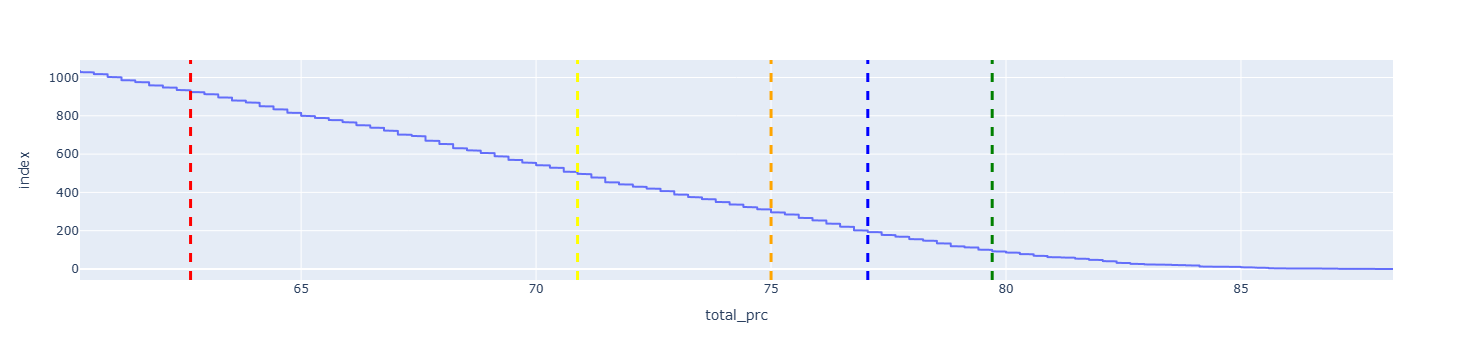

In [98]:
import plotly.express as px

df_fig = df[df['aprovado'] ]

# df é o seu DataFrame do Pandas com os dados do ranking
fig = px.line(df_fig, x="total_prc",y=df_fig.index)
# Se o total é 100 e você quer 50 bins, o size é 2
# fig.update_traces(xbins=dict(
#     size=1  # Força cada barra a ter largura 2
# ))

# # Ativando o Range Slider no eixo X
# fig.update_layout(
#     xaxis=dict(
#         rangeslider=dict(visible=True),
#         type="linear" # ou "date" para séries temporais
#     )
# )
# fig.update_layout(
#     height=800,  # Altura em pixels
#     # width=1000   # Opcional: Largura em pixels
# )
fig.add_vline(x=df_fig['total_prc'].iloc[100], line_width=3, line_dash="dash", line_color="green")
fig.add_vline(x=df_fig['total_prc'].iloc[200], line_width=3, line_dash="dash", line_color="blue")
fig.add_vline(x=df_fig['total_prc'].iloc[300], line_width=3, line_dash="dash", line_color="orange")
fig.add_vline(x=df_fig['total_prc'].iloc[500], line_width=3, line_dash="dash", line_color="yellow")
fig.add_vline(x=df[df_provas['usuario'] == 'cf_auditor']['total_prc'].iloc[0], line_width=3, line_dash="dash", line_color="red")


fig.show()